# Autocorrelation time

In this example we use the [pyALF](https://github.com/ALF-QMC/pyALF) interface to run ALF on a $4\times 4$ Hubbard square lattice, with the Mz choice of Hubbard-Stratonovich transformation, at $U/t=4$, half-band filling, and inverse temperature $\beta t = 5$.

Consecutive Monte Carlo bins are, in general, correlated: the update scheme performs *local* moves, so neighbouring configurations (and thus neighbouring bins) tend to be similar. If this autocorrelation is ignored, the naive bin-to-bin error underestimates the true statistical error.

The jackknife error estimate can be made robust against this by *rebinning*: grouping `N_rebin` consecutive raw bins into a single effective bin before performing the jackknife analysis. As `N_rebin` increases past the autocorrelation time (measured in units of bins), consecutive rebinned blocks become independent, and the estimated error saturates to its true value.

Bellow we go through the steps of running a simulation and estimating the autocorrelation time of the internal energy from the saturation of the error as a function of `N_rebin`.

---


**1.** Import `Simulation` class from the `py_alf` python module, which provides the interface with ALF, as well as mathematics and plotting packages:

In [1]:
from py_alf import Simulation, ALF_source  # Interface with ALF
#
import numpy as np                        # Numerical library
import matplotlib.pyplot as plt           # Plotting library
alf_src = ALF_source(branch='master')     # Obtain ALF source code


Checking out branch master
Your branch is up to date with 'origin/master'.


Already on 'master'


**2.** Create an instance of `Simulation`, specifying the necessary parameters. We deliberately use a small `NSweep` (number of sweeps per bin), so that consecutive bins remain significantly autocorrelated, making the rebinning analysis below meaningful:

In [2]:
sim = Simulation(
    alf_src,
    'Hubbard',                    # Hamiltonian
    {                             # Model and simulation parameters
        'Lattice_type': 'Square', #    Lattice type
        'L1': 4,                  #    Lattice length in the first unit vector direction
        'L2': 4,                  #    Lattice length in the second unit vector direction
        'Checkerboard': False,    #    Whether checkerboard decomposition is used or not
        'Symm': True,             #    Whether symmetrization takes place
        'ham_T': 1.0,             #    Hopping parameter
        'ham_U': 4.0,             #    Hubbard interaction
        'beta': 5.0,              #    Inverse temperature
        'Dtau': 0.1,              #    Trotter time step, Ltrot=beta/Dtau
        'Mz': True,               #    If true, sets the M_z-Hubbard model: Nf=2, N_sum=1,
                                  #             HS field couples to z-component of magnetization
        'NSweep': 5,              #    Number of sweeps per bin (kept small on purpose)
        'NBin': 2000,             #    Number of bins
    },
)


**3.** Compile ALF, downloading it first if not found locally. This may take a few minutes:

In [3]:
sim.compile()                            # Compilation needs to be performed only once


Checking out branch master
Your branch is up to date with 'origin/master'.


Already on 'master'


Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.


**4.** Perform the simulation and the default analysis:

In [4]:
sim.run()                                # Perform the actual simulation in ALF
sim.analysis()                           # Perform default (N_rebin=1) analysis
obs = sim.get_obs()
obs.iloc[0][['Ener_scal0', 'Ener_scal0_err']]


Prepare directory "/Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True" for Monte Carlo run.
Create new directory.
Run /Users/fassaad/Programs/ALF/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


### Analyzing /Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True ###
/Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
SpinT_eq
SpinXY_eq
SpinZ_eq
Time displaced observables:
Den_tau
Green_tau
SpinT_tau
SpinXY_tau
SpinZ_tau
/Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True
No orbital locations saved.


Ener_scal0       -13.199079
Ener_scal0_err     0.009902
Name: /Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True, dtype: object

**5.** Estimate the autocorrelation time of the internal energy.

We read the raw (unrebinned) Monte Carlo bins of `Ener_scal` directly, then repeatedly apply the jackknife analysis (`py_alf.ana.jack`/`error`) while increasing `N_rebin`, the number of raw bins combined into one effective bin. The resulting error should grow with `N_rebin` and then saturate once `N_rebin` exceeds the autocorrelation time (in units of bins):

In [5]:
from py_alf.ana import read_scal, jack, error   # Low-level analysis routines

# Raw, un-rebinned bins of the energy (bin average / sign)
bins_c, sign, N_obs = read_scal(sim.sim_dir, 'Ener_scal', bare_bins=True)
ener_bins = bins_c[:, 0].real / sign.real

N_skip = 100                                    # Bins discarded as warmup
N_rebin_max = (len(ener_bins) - N_skip) // 10    # Largest rebin size considered

errs = np.empty(N_rebin_max)
for N_rebin in range(1, N_rebin_max + 1):
    J = jack(ener_bins, par=None, N_skip=N_skip, N_rebin=N_rebin)
    _, err = error(J)
    errs[N_rebin - 1] = err


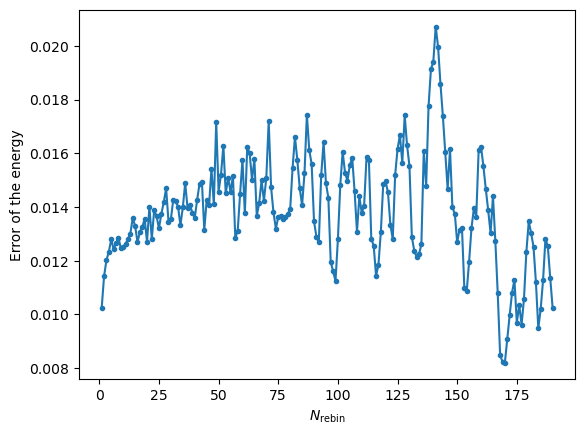

In [6]:
plt.figure()
plt.xlabel(r'$N_\mathrm{rebin}$')
plt.ylabel('Error of the energy')
plt.plot(range(1, N_rebin_max + 1), errs, '.-')


---

The error starts small (the naive, un-rebinned estimate underestimates the true error), rises as `N_rebin` grows, and then flattens out into a plateau. The value of `N_rebin` at which the curve saturates is an estimate, in units of bins, of the integrated autocorrelation time of the energy. Once `N_rebin` is chosen at or beyond this plateau (e.g., by setting `N_rebin` in the simulation parameters), the jackknife error becomes reliable.

## Exercises

1. Reduce `NSweep` further (e.g., to 1) and observe how the plateau shifts to larger `N_rebin`, indicating a longer autocorrelation time.
2. Increase `NSweep` (e.g., to 50 or 100) and check that the error is now roughly flat already at `N_rebin=1`, i.e., that individual bins are already effectively independent.
3. Repeat the analysis for a different observable (e.g., `Part_scal`) to see whether its autocorrelation time differs from that of the energy.
